In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input , Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np

from skimage.color import rgb2lab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/image_color"

In [4]:
image_name = os.listdir(dataset_path)[0]

print(image_name)

img = cv2.imread(os.path.join(dataset_path, image_name))

print(img.shape)

00000565_(3).jpg
(757, 1024, 3)


In [5]:
# resize image
IMG_SIZE = 128

img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

print(img.shape)

(128, 128, 3)


In [6]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [7]:
lab = rgb2lab(img)

print(lab.shape)

(128, 128, 3)


In [8]:
L = lab[:, :, 0]

ab = lab[:, :, 1:]

In [9]:
print(L.shape)

print(ab.shape)

(128, 128)
(128, 128, 2)


In [10]:
# normalize
L = L / 100.0

ab = ab / 128.0

In [11]:
X = []

Y = []

for file in os.listdir(dataset_path):

    path = os.path.join(dataset_path, file)

    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (128,128))

    lab = rgb2lab(img)

    L = lab[:,:,0]

    ab = lab[:,:,1:]

    X.append(L/100.0)

    Y.append(ab/128.0)

In [12]:
X = np.array(X)

Y = np.array(Y)

print(X.shape)

print(Y.shape)

(4319, 128, 128)
(4319, 128, 128, 2)


In [13]:
X = X.reshape((-1,128,128,1))
print(X.shape)

print(Y.shape)

(4319, 128, 128, 1)
(4319, 128, 128, 2)


In [14]:

input_img = Input(shape=(128, 128, 1))

# ---------------- Encoder ----------------
x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)

# ---------------- Decoder ----------------
x = UpSampling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

output = Conv2D(2, (3,3), activation='tanh', padding='same')(x)

model = Model(inputs=input_img, outputs=output)



In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 2)    │         1,154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,650 (2.82 MB)

 Trainable params: 739,650 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['accuracy']
)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3455, 128, 128, 1)
(864, 128, 128, 1)


In [19]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=50,
    batch_size=16,
    shuffle=True
)

Epoch 1/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.6890 - loss: 0.0123 - val_accuracy: 0.6978 - val_loss: 0.0126
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.6928 - loss: 0.0121 - val_accuracy: 0.7060 - val_loss: 0.0119
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.6896 - loss: 0.0122 - val_accuracy: 0.7004 - val_loss: 0.0125
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.6903 - loss: 0.0121 - val_accuracy: 0.6940 - val_loss: 0.0121
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.6916 - loss: 0.0121 - val_accuracy: 0.6968 - val_loss: 0.0119
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.6927 - loss: 0.0120 - val_accuracy: 0.6978 - val_loss: 0.0118
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.6925 - loss: 0.0120 - val_accuracy: 0.7033 - val_loss: 0.0119
Epoch 8/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.6967 - loss: 0.0119 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


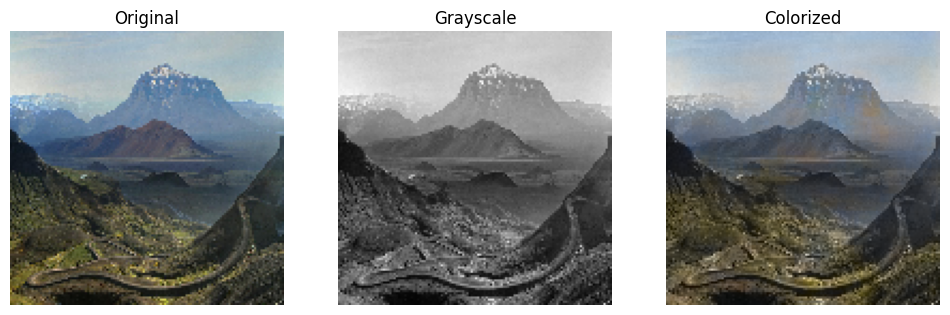

In [24]:
from skimage.color import rgb2lab, lab2rgb
img = cv2.imread("/content/drive/MyDrive/image_color/00000005_(4).jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

lab = rgb2lab(img)

L = lab[:, :, 0]

L_input = L / 100.0
L_input = L_input.reshape(1, IMG_SIZE, IMG_SIZE, 1)

pred_ab = model.predict(L_input)[0] * 128

lab_output = np.zeros((IMG_SIZE, IMG_SIZE, 3))
lab_output[:, :, 0] = L
lab_output[:, :, 1:] = pred_ab

colorized = lab2rgb(lab_output)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(L, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(colorized)
plt.title("Colorized")
plt.axis("off")

plt.show()

In [31]:

loss, accuracy = model.evaluate(X_test, Y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6910 - loss: 0.0121
Test Loss: 0.0121
Test Accuracy: 69.10%


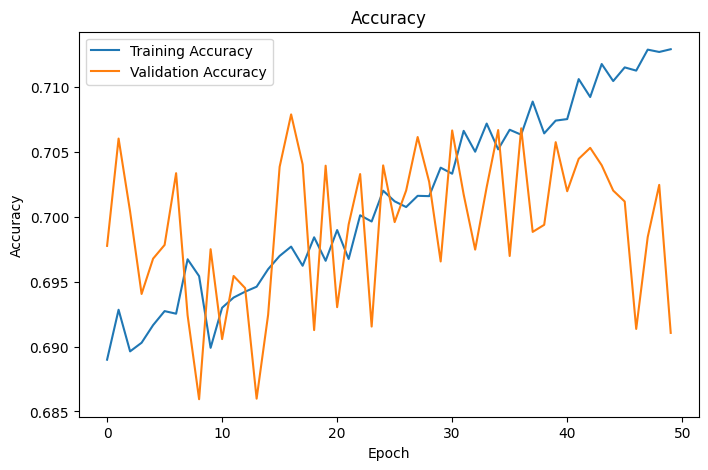

In [30]:

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()


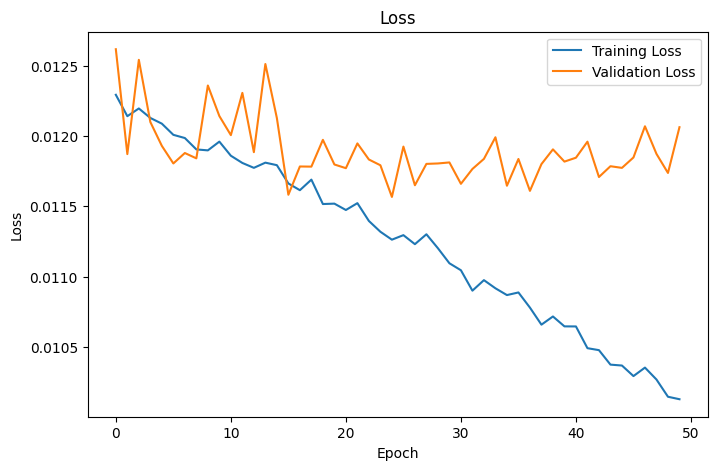

In [29]:

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.show()